# Vectorized micrograd — FER2013 Demo

**Version:** full training split + validation checkpointing + mixed mini-batches + input standardization.

Seven-class facial expression recognition on the FER2013 dataset —
the standard public benchmark for the same task studied in the NICE paper
(Dinh et al., ICLR 2015) under the Toronto Face Database (TFD).

| | MNIST | FER2013 |
|---|---|---|
| Input | 28 × 28 = 784 dims | 48 × 48 = 2 304 dims |
| Classes | 10 digits | 7 expressions |
| Train set | 60 000 | 28 709 |
| Test set | 10 000 | 3 589 |
| Human accuracy | ~98 % | ~65 % |

FER2013 is a genuinely hard dataset — human labellers agree only ~65 % of
the time, and the class distribution is heavily skewed toward *Happy*.

**Prerequisites — download the dataset before running this notebook.**

1. Create a free Kaggle account at <https://www.kaggle.com>.
2. Go to <https://www.kaggle.com/datasets/msambare/fer2013> and click **Download**.
3. Extract the zip. You will find two folders: `train/` and `test/`.  
   Each contains seven subfolders named after the expression class.
4. Place both folders in the same directory as this notebook:
   ```
   fer2013_demo.ipynb
   train/
     angry/   disgust/   fear/   happy/   neutral/   sad/   surprise/
   test/
     angry/   disgust/   fear/   happy/   neutral/   sad/   surprise/
   ```

The download is ~60 MB. Everything else runs with no extra dependencies beyond
Pillow (PIL), which ships with most Python distributions.


## Engine at a glance

`vect_engine.py` keeps the same interface as Karpathy's scalar `Value`
— `backward()`, `relu()`, operator overloads — but every node stores a full
NumPy array. The two pieces that make this non-trivial are:

* **`_unbroadcast`** — sums a broadcasted gradient back to the operand shape.
  When `b` has shape `(64,)` and `out = X @ W + b` has shape `(256, 64)`,
  the bias gradient must be summed over the batch dimension.
* **`__matmul__`** — explicit 2D backward
  (`dL/dX = dL/dY @ W.T`, `dL/dW = X.T @ dL/dY`).

With those two pieces in place the rest of the engine — add, mul, relu,
tanh, softmax_ce — is identical in structure to the scalar version.

## Building the MLP

`vect_nn.py` has two classes:

* **`Layer`** — weight matrix `W` (nin × nout) and bias `b` (nout,).  
  He initialisation: `W ~ N(0, sqrt(2/nin))`.
* **`MLP`** — stacks layers, applies the chosen activation between hidden
  layers, leaves the last layer linear.

FER2013 inputs are 2 304-dimensional (48 × 48 pixels flattened) — three
times wider than MNIST.  We use a `2304 → 512 → 256 → 7` network; the
wider first layer compensates for the richer input space.

In [29]:
import csv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from vect_micrograd.vect_engine import Value
from vect_micrograd.vect_nn import MLP
from vect_micrograd.optim import Adam, Lion
from vect_micrograd.utils import one_hot, cross_entropy_loss, save_checkpoint, load_checkpoint

EMOTION_NAMES = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
N_CLASSES     = len(EMOTION_NAMES)

## Loading FER2013

The Kaggle dataset uses an **image-folder layout**: one subfolder per class
inside `train/` and `test/`. The subfolder name is the label.

```
train/angry/   *.jpg   ← 3 995 images
train/happy/   *.jpg   ← 7 215 images
...
test/angry/    *.jpg   ←   467 images
...
```

The loader below reads every JPEG with `PIL.Image`, converts to greyscale,
flattens the 48 × 48 pixels to a 2 304-element vector, and normalises to
`[0, 1]`.  Class indices follow alphabetical subfolder order so they are
fully determined by the directory — no external label file needed.

In [30]:
import os
from PIL import Image

DATA_ROOT = '.'   # directory that contains train/ and test/

def load_fer2013_folders(root):
    """Load FER2013 from the image-folder layout used on Kaggle.

    Expected tree
    -------------
    root/
      train/
        angry/  disgust/  fear/  happy/  neutral/  sad/  surprise/
      test/
        angry/  disgust/  fear/  happy/  neutral/  sad/  surprise/

    Each leaf folder contains JPEG images (48 × 48 greyscale).

    Returns
    -------
    X_train : (28709, 2304) float64 in [0, 1]
    y_train : (28709,)      int
    X_test  : ( 3589, 2304) float64 in [0, 1]
    y_test  : ( 3589,)      int
    classes : list of str, length 7 (alphabetical order)
    """
    train_dir = os.path.join(root, 'train')
    classes   = sorted(os.listdir(train_dir))   # alphabetical → reproducible
    label_map = {cls: i for i, cls in enumerate(classes)}

    def read_split(split):
        X, y = [], []
        for cls in classes:
            folder = os.path.join(root, split, cls)
            if not os.path.isdir(folder):
                continue
            for fname in sorted(os.listdir(folder)):
                if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue
                img = Image.open(os.path.join(folder, fname)).convert('L')
                arr = np.array(img, dtype=float).ravel() / 255.0
                X.append(arr)
                y.append(label_map[cls])
        return np.stack(X), np.array(y, dtype=int)

    print('  reading train/ ...')
    X_train, y_train = read_split('train')
    print('  reading test/ ...')
    X_test,  y_test  = read_split('test')
    return X_train, y_train, X_test, y_test, classes


print(f'Reading from {os.path.abspath(DATA_ROOT)} ...')
X_train_raw, y_train_raw, X_test, y_test, EMOTION_NAMES = \
    load_fer2013_folders(DATA_ROOT)
N_CLASSES = len(EMOTION_NAMES)

print(f'Train : {X_train_raw.shape}  |  Test : {X_test.shape}')
print(f'Classes ({N_CLASSES}): {EMOTION_NAMES}')
print(f'Pixel range: [{X_train_raw.min():.2f}, {X_train_raw.max():.2f}]')

Reading from /home/r00t/Downloads/Karpathy/vect_micrograd_plus ...
  reading train/ ...
  reading test/ ...
Train : (28709, 2304)  |  Test : (7178, 2304)
Classes (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Pixel range: [0.00, 1.00]


## Class distribution

FER2013 is **not** balanced — *Happy* accounts for ~25 % of training examples
while *Disgust* is less than 2 %.  This imbalance is one of the reasons the
dataset is hard: a model that ignores Disgust still scores well on raw accuracy.

This notebook keeps the **entire** training split. Instead of creating a small
balanced subset, it balances each mini-batch by sampling approximately the same
number of images from every class. This gives the model more variety while still
preventing the majority classes from dominating each optimization step.


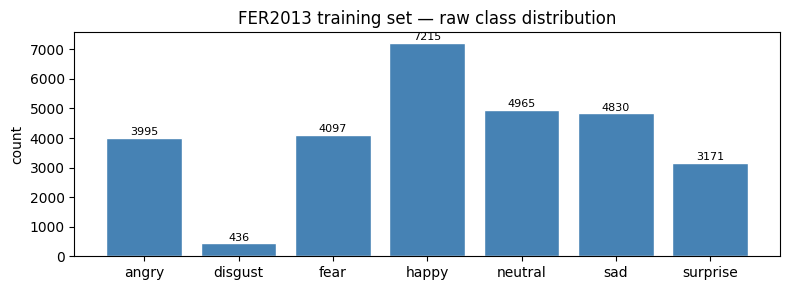

Counts per class:
  angry     :  3995  (13.9%)
  disgust   :   436  (1.5%)
  fear      :  4097  (14.3%)
  happy     :  7215  (25.1%)
  neutral   :  4965  (17.3%)
  sad       :  4830  (16.8%)
  surprise  :  3171  (11.0%)


In [31]:
# --- raw class counts ---
counts_raw = np.bincount(y_train_raw, minlength=N_CLASSES)

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.bar(EMOTION_NAMES, counts_raw, color='steelblue', edgecolor='white')
ax.set_ylabel('count')
ax.set_title('FER2013 training set — raw class distribution')
for bar, v in zip(bars, counts_raw):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 30,
            str(v), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print('Counts per class:')
for name, cnt in zip(EMOTION_NAMES, counts_raw):
    print(f'  {name:<10s}: {cnt:5d}  ({cnt/len(y_train_raw):.1%})')

## Full training split + validation split + mixed mini-batch sampler

The earlier version capped the data at `N_PER_CLASS = 400`, which produced only
2 800 training examples. This version keeps almost all training images, but
sets aside a small stratified validation split for checkpoint selection.

The raw images are kept in `[0, 1]` form for visualization and augmentation.
Before entering the MLP, images are standardized using per-pixel mean and
standard deviation computed from the training split only.

The mini-batch sampler is **mixed**: part class-balanced, part natural-frequency.
Fully balanced batches can over-sample rare classes such as *Disgust* very
aggressively. Mixed batches still help minority classes while keeping the
optimization distribution closer to the raw test distribution.


Train-fit raw : (25841, 2304)
Validation    : (2868, 2304)
Test          : (7178, 2304)
Norm check    : mean=0.000, std=1.000


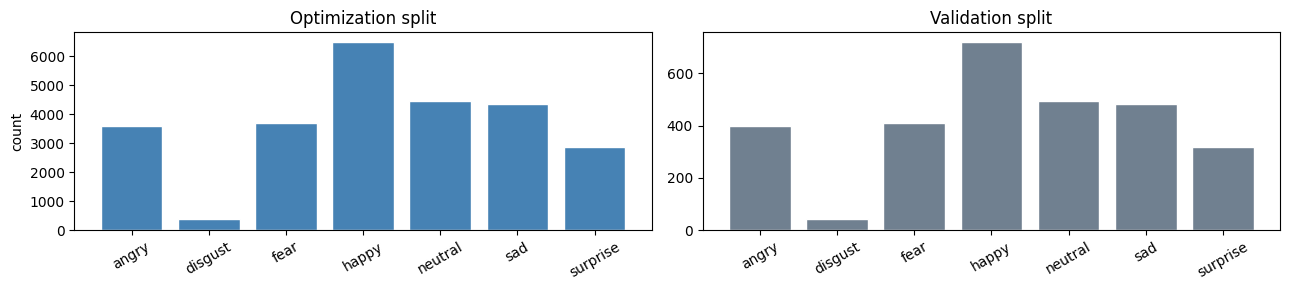

In [32]:
def stratified_train_val_split(X, y, val_frac=0.10, seed=123):
    rng = np.random.default_rng(seed)

    train_idx = []
    val_idx = []

    for c in range(N_CLASSES):
        idx = np.where(y == c)[0].copy()
        rng.shuffle(idx)

        n_val = max(1, int(len(idx) * val_frac))
        val_idx.append(idx[:n_val])
        train_idx.append(idx[n_val:])

    train_idx = np.concatenate(train_idx)
    val_idx = np.concatenate(val_idx)

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


# Raw arrays for augmentation and visualization.
X_train_raw_fit, y_train, X_val_raw, y_val = stratified_train_val_split(
    X_train_raw,
    y_train_raw,
    val_frac=0.10,
    seed=123,
)

Y_train = one_hot(y_train, classes=N_CLASSES)
Y_val   = one_hot(y_val,   classes=N_CLASSES)

# Per-pixel standardization. Fit statistics on train-fit only.
X_mean = X_train_raw_fit.mean(axis=0, keepdims=True)
X_std  = X_train_raw_fit.std(axis=0, keepdims=True) + 1e-6

def normalize_X(X):
    return (X - X_mean) / X_std

# Fixed normalized arrays for validation and final test.
X_val        = normalize_X(X_val_raw)
X_test_norm  = normalize_X(X_test)

# Precompute class index lists once.
class_indices = [np.where(y_train == c)[0] for c in range(N_CLASSES)]

def sample_balanced_batch_indices(batch_size, rng):
    """Uniform over classes, with replacement inside each class."""
    base = batch_size // N_CLASSES
    remainder = batch_size % N_CLASSES

    extra_classes = set(rng.choice(N_CLASSES, size=remainder, replace=False))
    pieces = []

    for c, idx_c in enumerate(class_indices):
        k = base + (1 if c in extra_classes else 0)
        pieces.append(rng.choice(idx_c, size=k, replace=True))

    idx = np.concatenate(pieces)
    rng.shuffle(idx)
    return idx

def sample_natural_batch_indices(batch_size, rng):
    """Natural class-frequency sampling from the training split."""
    return rng.choice(len(y_train), size=batch_size, replace=True)

def sample_mixed_batch_indices(batch_size, rng, balanced_frac=0.50):
    """Part balanced, part natural-frequency.

    balanced_frac=1.0 gives fully balanced batches.
    balanced_frac=0.0 gives ordinary natural-frequency batches.
    """
    n_bal = int(round(batch_size * balanced_frac))
    n_nat = batch_size - n_bal

    pieces = []
    if n_bal > 0:
        pieces.append(sample_balanced_batch_indices(n_bal, rng))
    if n_nat > 0:
        pieces.append(sample_natural_batch_indices(n_nat, rng))

    idx = np.concatenate(pieces)
    rng.shuffle(idx)
    return idx

print(f'Train-fit raw : {X_train_raw_fit.shape}')
print(f'Validation    : {X_val.shape}')
print(f'Test          : {X_test_norm.shape}')
print(f'Norm check    : mean={normalize_X(X_train_raw_fit).mean():.3f}, '
      f'std={normalize_X(X_train_raw_fit).std():.3f}')

counts_train = np.bincount(y_train, minlength=N_CLASSES)
counts_val   = np.bincount(y_val, minlength=N_CLASSES)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3))

ax1.bar(EMOTION_NAMES, counts_train, color='steelblue', edgecolor='white')
ax1.set_title('Optimization split')
ax1.set_ylabel('count')
ax1.tick_params(axis='x', rotation=30)

ax2.bar(EMOTION_NAMES, counts_val, color='slategray', edgecolor='white')
ax2.set_title('Validation split')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## A look at the data

Each image is a 48 × 48 greyscale face aligned and cropped to a fixed bounding
box.  Unlike MNIST the intra-class variation is high — the same expression can
look very different across age, gender, lighting, and ethnicity.

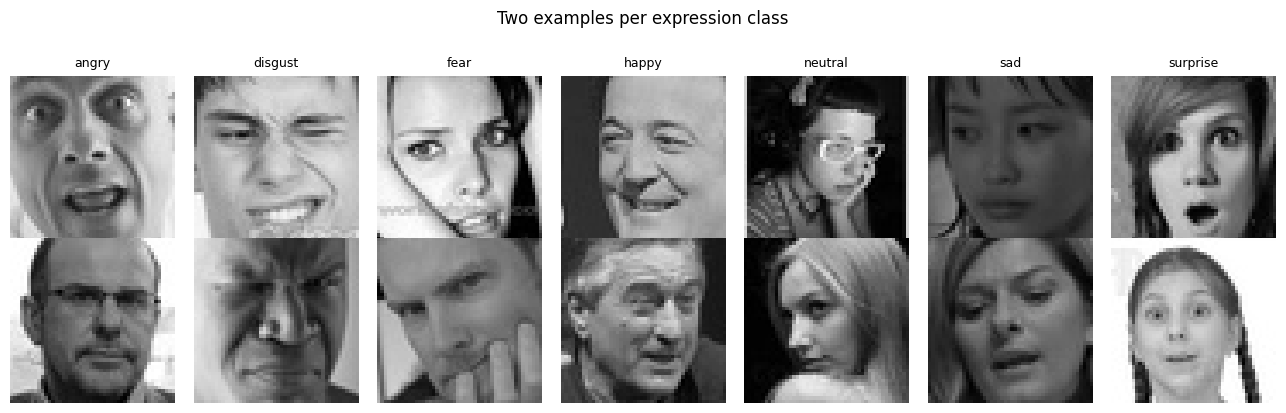

In [33]:
fig, axes = plt.subplots(2, N_CLASSES, figsize=(13, 4))

for c, name in enumerate(EMOTION_NAMES):
    examples = X_train_raw_fit[y_train == c][:2]
    for row, img in enumerate(examples):
        axes[row, c].imshow(img.reshape(48, 48), cmap='gray', vmin=0, vmax=1)
        axes[row, c].axis('off')
        if row == 0:
            axes[row, c].set_title(name, fontsize=9)

plt.suptitle('Two examples per expression class', y=1.02)
plt.tight_layout()
plt.show()


## Model

A three-layer MLP with ReLU activations:

```
2304  →  512  →  256  →  7
         ReLU    ReLU    (linear logits)
```

This is still a raw-pixel MLP, not a CNN. The expected ceiling is limited,
but standardized inputs, validation checkpointing, and gentler augmentation
usually make the baseline more stable.


In [34]:
np.random.seed(42)

model = MLP(2304, [512, 256, 7])

print(model)
print(f'Scalar parameters : {sum(p.data.size for p in model.parameters()):,}')
print(f'Value nodes       : {len(model.parameters())}  '
      f'(vs ~{sum(p.data.size for p in model.parameters()):,} in scalar micrograd)')

MLP of [Layer(2304, 512), Layer(512, 256), Layer(256, 7)]
Scalar parameters : 1,313,287
Value nodes       : 6  (vs ~1,313,287 in scalar micrograd)


## Training

The loop below is more conservative than the previous version:

1. Draw a **mixed** mini-batch: half balanced, half natural-frequency.
2. Apply very light augmentation.
3. Standardize the augmented batch before the MLP.
4. Update the model with Adam.
5. Select the best checkpoint using fixed, unaugmented validation accuracy.

The validation set is not augmented and is not used for optimization.


### Batch augmentation

In [35]:
def augment_batch(Xb, rng, p_flip=0.5, max_shift=0, noise_std=0.01):
    """
    Xb shape: (batch, 2304), raw pixels in [0, 1].

    For a flattened-pixel MLP, keep augmentation light.
    Large shifts/rotations are better suited to CNNs because CNNs have spatial
    weight sharing; a raw MLP does not.
    """
    imgs = Xb.reshape(-1, 48, 48).copy()

    for i in range(len(imgs)):
        # horizontal flip
        if rng.random() < p_flip:
            imgs[i] = imgs[i, :, ::-1]

        # optional tiny translation
        if max_shift > 0:
            dy = rng.integers(-max_shift, max_shift + 1)
            dx = rng.integers(-max_shift, max_shift + 1)
            imgs[i] = np.roll(imgs[i], shift=(dy, dx), axis=(0, 1))

            # remove wrap-around artifacts from np.roll
            fill = float(imgs[i].mean())

            if dy > 0:
                imgs[i, :dy, :] = fill
            elif dy < 0:
                imgs[i, dy:, :] = fill

            if dx > 0:
                imgs[i, :, :dx] = fill
            elif dx < 0:
                imgs[i, :, dx:] = fill

    if noise_std > 0:
        imgs += rng.normal(0.0, noise_std, size=imgs.shape)

    imgs = np.clip(imgs, 0.0, 1.0)
    return imgs.reshape(len(imgs), -1)

## EMA-smoothed model

In [36]:
def copy_checkpoint(ckpt):
    return [x.copy() for x in ckpt]

def update_ema_checkpoint(model, ema_checkpoint, decay=0.995):
    """
    ema = decay * ema + (1 - decay) * current_params
    """
    for ema_param, p in zip(ema_checkpoint, model.parameters()):
        ema_param *= decay
        ema_param += (1.0 - decay) * p.data

STEPS      = 4000
BATCH_SIZE = 256
L2_ALPHA   = 1e-3
EVAL_EVERY = 50

EMA_START = 500
EMA_DECAY = 0.995

optimizer = Adam(model.parameters(), lr=5e-4, total_steps=STEPS, weight_decay=0)

best_checkpoint = None
best_val_acc = -1.0
best_val_loss = float("inf")
best_step = -1

ema_checkpoint = None

history = []   # (step, batch_loss, batch_acc, val_loss, val_acc)

rng = np.random.default_rng(7)

for k in range(STEPS):
    ri = sample_mixed_batch_indices(BATCH_SIZE, rng, balanced_frac=0.50)

    # Raw image batch -> light augmentation -> standardization.
    Xb_raw = X_train_raw_fit[ri]
    Yb = Y_train[ri]

    Xb_raw = augment_batch(Xb_raw, rng, p_flip=0.5, max_shift=0, noise_std=0.01)
    Xb = normalize_X(Xb_raw)

    batch_loss, batch_acc = cross_entropy_loss(model, Xb, Yb, alpha=L2_ALPHA)

    optimizer.zero_grad()
    batch_loss.backward()
    optimizer.step(k)

    # Update EMA after the optimizer update.
    if k == EMA_START:
        ema_checkpoint = save_checkpoint(model)
    elif k > EMA_START:
        update_ema_checkpoint(model, ema_checkpoint, decay=EMA_DECAY)

    if k % EVAL_EVERY == 0 or k == STEPS - 1:
        # Validate EMA model if available.
        # Otherwise validate the current model.
        if ema_checkpoint is not None:
            current_checkpoint = save_checkpoint(model)
            load_checkpoint(model, ema_checkpoint)
            val_loss, val_acc = cross_entropy_loss(model, X_val, Y_val, alpha=0.0)
            candidate_checkpoint = save_checkpoint(model)
            load_checkpoint(model, current_checkpoint)
        else:
            val_loss, val_acc = cross_entropy_loss(model, X_val, Y_val, alpha=0.0)
            candidate_checkpoint = save_checkpoint(model)

        val_loss_item = val_loss.item()

        history.append((k, batch_loss.item(), batch_acc, val_loss_item, val_acc))

        print(
            f"step {k:4d}  "
            f"batch loss {batch_loss.item():.4f}  "
            f"batch acc {batch_acc:.2%}  "
            f"ema val loss {val_loss_item:.4f}  "
            f"ema val acc {val_acc:.2%}"
        )

        ACC_TOL = 0.005   # 0.5 percentage points
        improved = False
        if val_acc > best_val_acc + ACC_TOL:
            improved = True
        elif val_acc >= best_val_acc - ACC_TOL and val_loss_item < best_val_loss:
            improved = True

        if improved:
            best_val_acc = val_acc
            best_val_loss = val_loss_item
            best_step = k
            best_checkpoint = copy_checkpoint(candidate_checkpoint)

print()
print(
    f"Best EMA checkpoint at step {best_step}, "
    f"val acc {best_val_acc:.2%}, "
    f"val loss {best_val_loss:.4f}"
)

step    0  batch loss 4.0576  batch acc 12.89%  ema val loss 2.4038  ema val acc 18.83%
step   50  batch loss 3.1761  batch acc 32.81%  ema val loss 1.7653  ema val acc 32.32%
step  100  batch loss 3.0881  batch acc 39.06%  ema val loss 1.7042  ema val acc 35.67%
step  150  batch loss 2.9183  batch acc 44.92%  ema val loss 1.6848  ema val acc 35.60%
step  200  batch loss 2.7999  batch acc 46.88%  ema val loss 1.6528  ema val acc 36.54%
step  250  batch loss 2.7458  batch acc 43.75%  ema val loss 1.6361  ema val acc 37.55%
step  300  batch loss 2.6835  batch acc 40.62%  ema val loss 1.6421  ema val acc 37.97%
step  350  batch loss 2.5108  batch acc 50.78%  ema val loss 1.6003  ema val acc 40.48%
step  400  batch loss 2.4336  batch acc 52.73%  ema val loss 1.5935  ema val acc 38.81%
step  450  batch loss 2.4384  batch acc 49.22%  ema val loss 1.5729  ema val acc 41.70%
step  500  batch loss 2.3499  batch acc 52.34%  ema val loss 1.5630  ema val acc 41.67%
step  550  batch loss 2.2705  ba

## Training curves

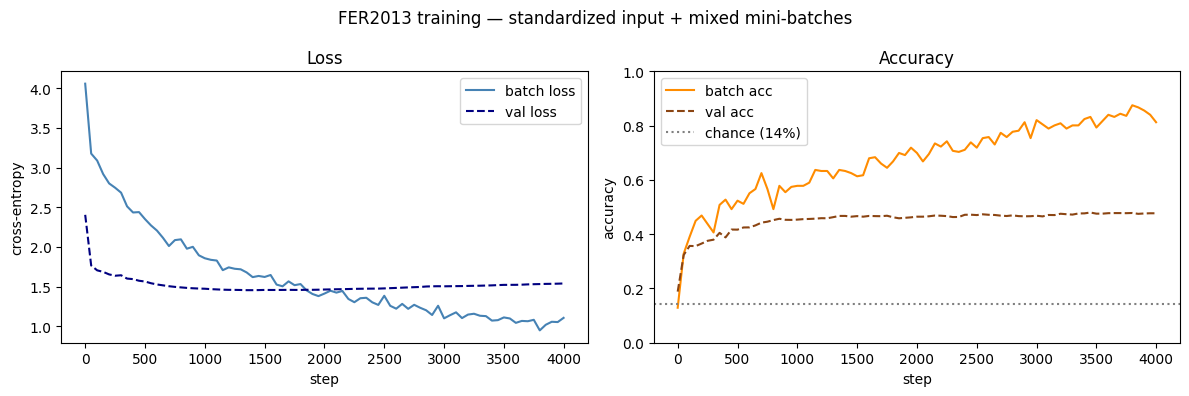

In [43]:
hist         = np.array(history)
steps_logged = hist[:, 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(steps_logged, hist[:, 1], color='steelblue',   label='batch loss')
ax1.plot(steps_logged, hist[:, 3], color='navy',        label='val loss', linestyle='--')
ax1.set_xlabel('step')
ax1.set_ylabel('cross-entropy')
ax1.set_title('Loss')
ax1.legend()

ax2.plot(steps_logged, hist[:, 2], color='darkorange',  label='batch acc')
ax2.plot(steps_logged, hist[:, 4], color='saddlebrown', label='val acc',  linestyle='--')
ax2.axhline(1/N_CLASSES, color='gray', linestyle=':', label=f'chance ({1/N_CLASSES:.0%})')
ax2.set_xlabel('step')
ax2.set_ylabel('accuracy')
ax2.set_ylim(0, 1)
ax2.set_title('Accuracy')
ax2.legend()

plt.suptitle('FER2013 training — standardized input + mixed mini-batches')
plt.tight_layout()
plt.show()


## Test-set evaluation

Restore the best validation checkpoint and run a single forward pass over the
full test split. The test set is never used for training or checkpoint
selection.


In [44]:
load_checkpoint(model, best_checkpoint)

test_logits = model(Value(X_test_norm))
test_preds  = test_logits.data.argmax(axis=1)
test_acc    = float((test_preds == y_test).mean())

print(f'Restored checkpoint from step {best_step}')
print(f'Test accuracy : {test_acc:.2%}  '
      f'({int(test_acc * len(y_test)):,} / {len(y_test):,} correct)')
print(f'Chance baseline : {1/N_CLASSES:.2%}')
print(f'Human accuracy  : ~65 %')


Restored checkpoint from step 3450
Test accuracy : 47.44%  (3,405 / 7,178 correct)
Chance baseline : 14.29%
Human accuracy  : ~65 %


## Confusion matrix

Which expressions does the model confuse most? The off-diagonal structure
reveals systematic errors — e.g. *Fear* and *Sad* are commonly swapped,
and *Disgust* often collapses into *Angry*.

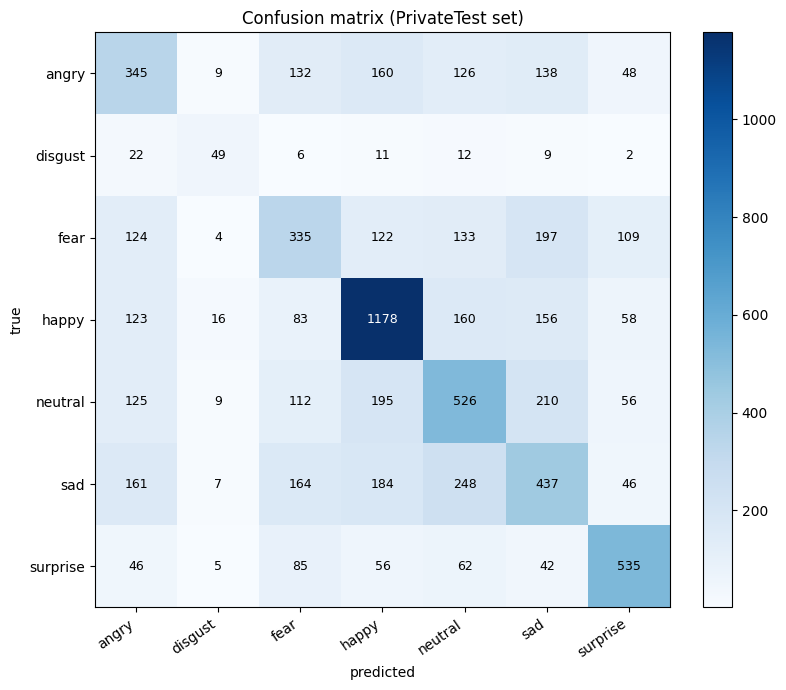

In [39]:
C = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
for true, pred in zip(y_test, test_preds):
    C[true, pred] += 1

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(C, cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.046)

ax.set_xticks(range(N_CLASSES))
ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(EMOTION_NAMES, rotation=35, ha='right')
ax.set_yticklabels(EMOTION_NAMES)
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('Confusion matrix (PrivateTest set)')

for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        color = 'white' if C[i, j] > C.max() / 2 else 'black'
        ax.text(j, i, str(C[i, j]), ha='center', va='center', fontsize=9, color=color)

plt.tight_layout()
plt.show()

## Hard cases — misclassified faces

A random sample of mistakes. Note that many of these are ambiguous even
to a human — the dataset label is not always the only reasonable reading
of the expression.

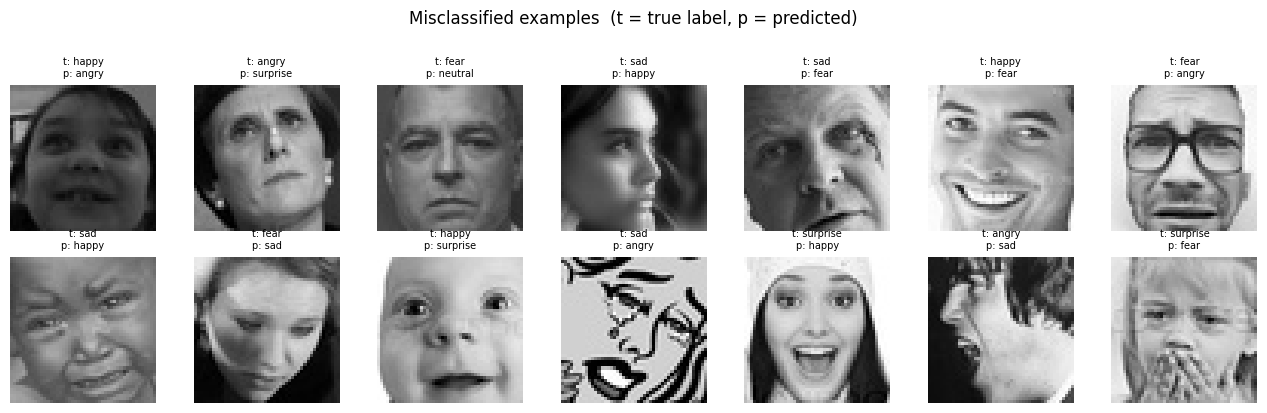

3773 misclassifications out of 7178 test images


In [40]:
wrong_idx = np.where(test_preds != y_test)[0]
show      = np.random.default_rng(1).choice(wrong_idx, size=14, replace=False)

fig, axes = plt.subplots(2, 7, figsize=(13, 4))
for ax, i in zip(axes.ravel(), show):
    ax.imshow(X_test[i].reshape(48, 48), cmap='gray', vmin=0, vmax=1)
    t = EMOTION_NAMES[y_test[i]]
    p = EMOTION_NAMES[test_preds[i]]
    ax.set_title(f't: {t}\np: {p}', fontsize=7)
    ax.axis('off')

plt.suptitle('Misclassified examples  (t = true label, p = predicted)', y=1.02)
plt.tight_layout()
plt.show()

print(f'{len(wrong_idx)} misclassifications out of {len(y_test)} test images')

## Per-class accuracy

Class-level accuracy exposes the imbalance effect even with balanced training:
*Happy* is typically the easiest class while *Disgust* and *Fear* are hardest,
consistent with the literature.

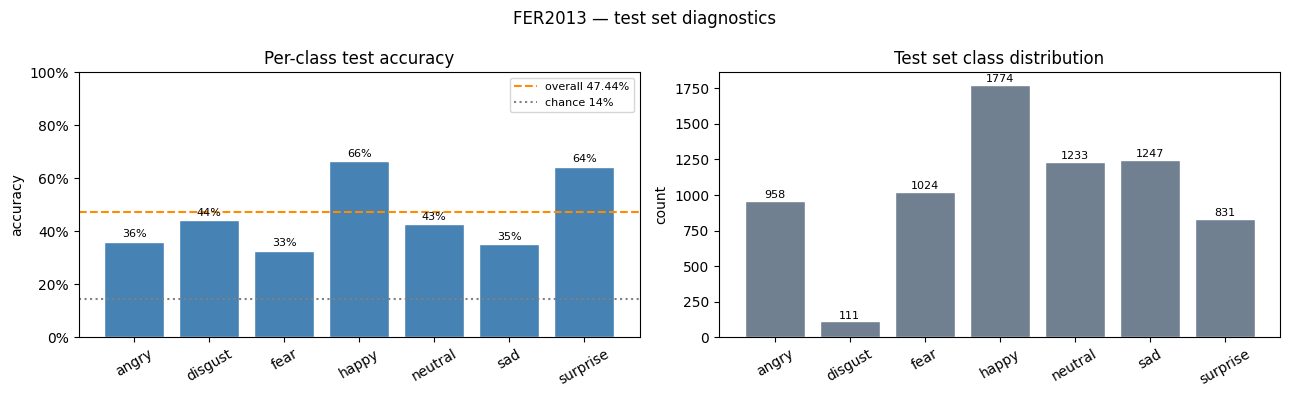

In [41]:
per_class = [
    float((test_preds[y_test == c] == c).mean())
    for c in range(N_CLASSES)
]

# test set size per class (imbalanced)
test_counts = np.bincount(y_test, minlength=N_CLASSES)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# --- per-class accuracy ---
bars = ax1.bar(EMOTION_NAMES, per_class, color='steelblue', edgecolor='white')
ax1.axhline(test_acc,      color='darkorange', linestyle='--', label=f'overall {test_acc:.2%}')
ax1.axhline(1/N_CLASSES,   color='gray',       linestyle=':',  label=f'chance {1/N_CLASSES:.0%}')
ax1.set_ylim(0, 1)
ax1.set_ylabel('accuracy')
ax1.set_title('Per-class test accuracy')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax1.tick_params(axis='x', rotation=30)
ax1.legend(fontsize=8)
for bar, v in zip(bars, per_class):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
             f'{v:.0%}', ha='center', va='bottom', fontsize=8)

# --- test set class distribution ---
ax2.bar(EMOTION_NAMES, test_counts, color='slategray', edgecolor='white')
ax2.set_ylabel('count')
ax2.set_title('Test set class distribution')
ax2.tick_params(axis='x', rotation=30)
for bar, v in zip(ax2.patches, test_counts):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 5,
             str(v), ha='center', va='bottom', fontsize=8)

plt.suptitle('FER2013 — test set diagnostics')
plt.tight_layout()
plt.show()

## Softmax probability distributions

For a handful of correct and incorrect predictions, we plot the full softmax
distribution to see how confident the model is. A peaked distribution on the
wrong class is a harder failure than a flat, uncertain one.

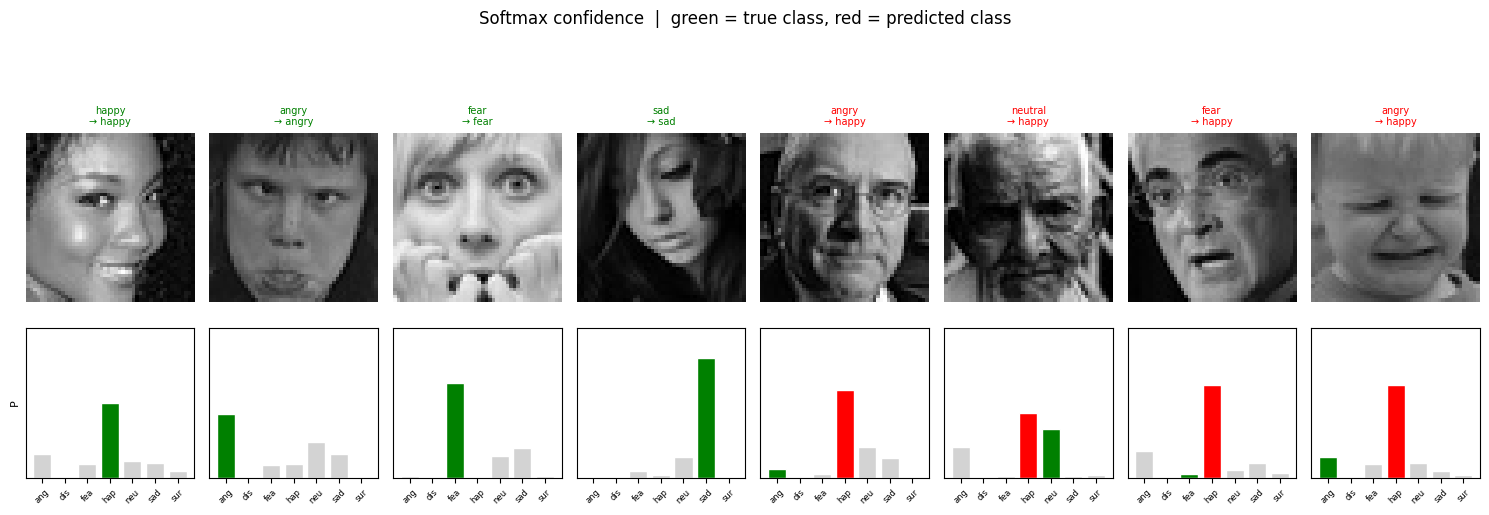

In [42]:
# Compute softmax probabilities for the full test set
logits_np = test_logits.data.copy()                   # (n_test, 7)
logits_np -= logits_np.max(axis=1, keepdims=True)     # numerical stability
exp_l      = np.exp(logits_np)
probs_all  = exp_l / exp_l.sum(axis=1, keepdims=True) # (n_test, 7)

correct_idx   = np.where(test_preds == y_test)[0]
incorrect_idx = np.where(test_preds != y_test)[0]

rng_show = np.random.default_rng(3)
show_correct   = rng_show.choice(correct_idx,   size=4, replace=False)
show_incorrect = rng_show.choice(incorrect_idx, size=4, replace=False)
show_all = np.concatenate([show_correct, show_incorrect])

fig, axes = plt.subplots(2, 8, figsize=(15, 5),
                         gridspec_kw={'height_ratios': [2, 1]})

for col, i in enumerate(show_all):
    # face image
    axes[0, col].imshow(X_test[i].reshape(48, 48), cmap='gray', vmin=0, vmax=1)
    axes[0, col].axis('off')
    correct = (test_preds[i] == y_test[i])
    color   = 'green' if correct else 'red'
    axes[0, col].set_title(
        f"{EMOTION_NAMES[y_test[i]]}\n→ {EMOTION_NAMES[test_preds[i]]}",
        fontsize=7, color=color)

    # probability bar
    bar_colors = ['green' if j == y_test[i] else
                  'red'   if j == test_preds[i] else
                  'lightgray'
                  for j in range(N_CLASSES)]
    axes[1, col].bar(range(N_CLASSES), probs_all[i], color=bar_colors, edgecolor='white')
    axes[1, col].set_ylim(0, 1)
    axes[1, col].set_xticks(range(N_CLASSES))
    axes[1, col].set_xticklabels([n[:3] for n in EMOTION_NAMES], fontsize=6, rotation=45)
    axes[1, col].set_yticks([])
    if col == 0:
        axes[1, col].set_ylabel('P', fontsize=8)

axes[0, 0].set_ylabel('Correct ✓', fontsize=9, color='green')
axes[0, 4].set_ylabel('Wrong ✗', fontsize=9, color='red')

plt.suptitle('Softmax confidence  |  green = true class, red = predicted class', y=1.02)
plt.tight_layout()
plt.show()
